In [52]:
import random
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display 

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile 
from qiskit_aer import Aer
from qiskit_aer import AerSimulator

from qiskit_aer.noise import NoiseModel, depolarizing_error

# Supendense coding

Superdense coding allows Alice to send 2 classical bits using only 1 qubit, provided that Alice and Bob already share an entangled Bell pair.


**Step 1: Alice encodes:**

Alice wants to send 10.


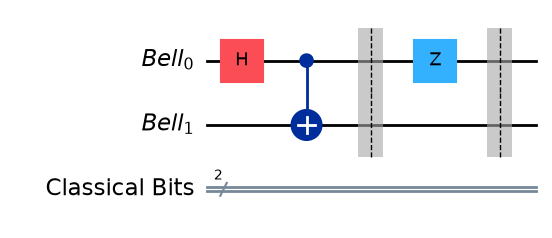

In [68]:
def create_bell_pair(qc, bell):
    qc.h(bell[0])
    qc.cx(bell[0], bell[1])
    qc.barrier()

def alice_encode(qc, bell, b1, b2):
    if b2 == 1:
        qc.x(bell[0])
    if b1 == 1:
        qc.z(bell[0])

    qc.barrier()

def bob_decode(qc, bell, c):
    qc.cx(bell[0], bell[1])
    qc.h(bell[0])
    qc.barrier()

    qc.measure(bell, c)

# We start by creating the two-qubit register that Alice and Bob will share:
bell = QuantumRegister(2, name = 'Bell')     
c = ClassicalRegister(2, name='Classical Bits')                 

# Create our circuit and prepare the shared Bell pair:
superdense_qc = QuantumCircuit(bell,c)            
create_bell_pair(superdense_qc, bell)

# We randomly choose which bits to send:
b1 = random.randint(0,1)
b2 = random.randint(0,1)

print(f"Alice wants to send {b1}{b2}.")


# Alice encodes the two classical bits by applying the corresponding gates to her qubit:
alice_encode(superdense_qc, bell, b1, b2)

encoded_qc = superdense_qc.copy()


display(superdense_qc.draw('mpl'))





**Step 2: Bob Decodes**

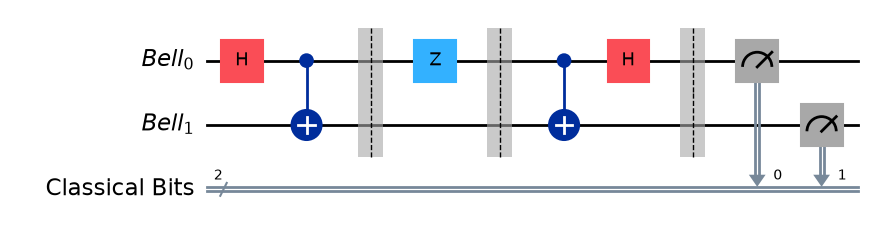

In [69]:
superdense_qc = encoded_qc.copy()

# Alice sends her qubit to Bob. Bob then decodes the message and measures both qubits:
bob_decode(superdense_qc, bell, c)

display(superdense_qc.draw('mpl'))

**Step 3: Run the Circuit and Check What Bob Receives**

In [70]:
# As usual, first set the backend:
backend = Aer.get_backend('qasm_simulator')

# Transpile and run the circuit:
transpiled_superdense_qc = transpile(superdense_qc, backend)
job = backend.run(transpiled_superdense_qc, shots=1, memory=True)
result = job.result().get_memory()

print(f"Bob has received {result[0][1]}{result[0][0]}.")

Bob has received 10.


**Step 4: Superdense Coding with Noise**

In [71]:
# Define error probabilities
p1 = 0.01   # single-qubit gate error
p2 = 0.02   # two-qubit gate error

# Create depolarizing errors
error_1q = depolarizing_error(p1, 1)
error_2q = depolarizing_error(p2, 2)

# Create the noise model
noise_model = NoiseModel()

noise_model.add_all_qubit_quantum_error(error_1q, ['h', 'x', 'z'])
noise_model.add_all_qubit_quantum_error(error_2q, ['cx'])


# Transpile and run the noisy circuit:
backend = Aer.get_backend('qasm_simulator')

transpiled_noisy_qc = transpile(superdense_qc, backend)

job = backend.run(
    transpiled_noisy_qc,
    shots=1000,
    noise_model=noise_model
)

result = job.result()
counts = result.get_counts()

print(f"Alice sent: {b1}{b2}")
print("Bob's results:", counts)


Alice sent: 10
Bob's results: {'10': 10, '00': 21, '11': 15, '01': 954}


**Step 5: Success Rate**

In [72]:
correct_message = f"{b2}{b1}"

correct_counts = counts.get(correct_message, 0)
success_rate = correct_counts / 1000

print(f"Success rate: {success_rate:.2%}")

Success rate: 95.40%
